## Install AlphaGenome  
https://github.com/google-deepmind/alphagenome_research/tree/main

In [12]:

# !git clone https://github.com/google-deepmind/alphagenome_research.git
# !pip install -e ./alphagenome_research

In [13]:
import os
import jax

os.environ["JAX_PLATFORM_NAME"] = "gpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print(jax.devices())
print("default backend:", jax.default_backend())


[CudaDevice(id=0)]
default backend: gpu


In [14]:
from alphagenome.data import genome
from alphagenome.visualization import plot_components
from alphagenome_research.model import dna_model
from alphagenome.models import variant_scorers
from alphagenome.models import dna_client

import matplotlib.pyplot as plt
import functools
from typing import Callable
from typing import Tuple, List
import pyranges as pr
from tqdm import tqdm
import numpy as np
import pandas as pd
from dataclasses import dataclass
from scipy.stats import pearsonr, spearmanr
from sklearn import metrics
from sklearn.metrics import average_precision_score, roc_auc_score

## Data preparation

In [15]:
# results from Pedro

df = pd.read_parquet(
    "/s/project/benchmark-lm/data/orthology_primates/preds/gnomad_indels_scores/all_tracks_variant_gene_scores_all_species_ENSG00000075539.parquet"
)

print(df.head())
print(df.shape)
print(df.columns)

   selected_exon_bp  track_idx                     track_name track_strand  \
0              9468        271  CL:0000047 polyA plus RNA-seq            -   
1              9468        272       CL:0000062 total RNA-seq            -   
2              9468        273  CL:0000084 polyA plus RNA-seq            -   
3              9468        274       CL:0000084 total RNA-seq            -   
4              9468        275       CL:0000115 total RNA-seq            -   

  assay_type         assay_title  assay_track_idx  rna_seq_track_idx  \
0    rna_seq  polyA plus RNA-seq                0                271   
1    rna_seq       total RNA-seq                1                272   
2    rna_seq  polyA plus RNA-seq                2                273   
3    rna_seq       total RNA-seq                3                274   
4    rna_seq       total RNA-seq                4                275   

              rna_seq_track_name  track_metadata_idx  ...  \
0  CL:0000047 polyA plus RNA-seq     

In [16]:
df.Gene.unique()

array(['ENSG00000075539'], dtype=object)

In [17]:
# gene annotation

df_GCA = pd.read_feather(
    "data/exons/GCA_000001405.29.feather"
)

In [18]:
df_GCA.columns

Index(['Chromosome', 'Source', 'Feature', 'Start', 'End', 'Score', 'Strand',
       'Frame', 'ID', 'Dbxref', 'Name', 'chromosome', 'gbkey', 'genome',
       'mol_type', 'description', 'gene', 'gene_biotype', 'pseudo', 'Parent',
       'product', 'transcript_id', 'gene_synonym', 'Note', 'experiment',
       'function', 'regulatory_class', 'standard_name', 'model_evidence',
       'tag', 'protein_id', 'inference', 'recombination_class', 'feat_class',
       'rpt_type', 'rpt_unit_seq', 'exception', 'anticodon', 'partial',
       'start_range', 'end_range', 'mobile_element_type', 'rpt_family',
       'transl_except', 'satellite', 'bound_moiety', 'Target',
       'assembly_bases_aln', 'assembly_bases_seq', 'bit_score',
       'blast_aligner', 'blast_score', 'common_component', 'e_value',
       'filter_score', 'for_remapping', 'gap_count', 'hsp_percent_coverage',
       'matchable_bases', 'matched_bases', 'num_ident', 'num_mismatch',
       'pct_coverage', 'pct_coverage_hiqual', 'pct_identi

In [19]:
df_GCA.Name.unique()

array(['1', 'DDX11L1', 'NR_046018.2', ..., 'YP_003024038.1', 'TRNT',
       'TRNP'], shape=(381380,), dtype=object)

In [20]:
# prepare data GCA_000001405.29.parquet

# copy dataframe
df_out = df_GCA

df_out = df_out[
    df_out["Feature"].isin(["CDS", "cds", "transcript", "gene"])
].copy()

# rename CDS -> exon

df_out["Feature"] = (
    df_out["Feature"]
    .astype(str)
    .str.strip()
)

df_out["Feature"] = df_out["Feature"].replace({
    "CDS": "exon",
    "cds": "exon",
})

# rename gene column -> gene_id
df_out["gene_name"] = df_out["Name"]
df_out = df_out.rename(columns={
    "gene": "gene_id"
})
df_out["gene_type"] = df_out["gene_biotype"]
# optional: remove rows without gene_id

df_out = df_out[df_out["gene_id"].notna()]

# save as feather

df_out.to_feather("data/exons/TP53_annotation_geneid_exons.feather")

print(df_out["Feature"].value_counts())

print(df_out.head())

Feature
exon          1839374
gene            48106
transcript      15023
Name: count, dtype: int64
    Chromosome      Source     Feature  Start    End Score Strand Frame  \
2   CM000663.2  BestRefSeq  transcript  11873  14409     .      +     .   
7   CM000663.2  BestRefSeq  transcript  14361  29370     .      -     .   
19  CM000663.2  BestRefSeq        gene  17368  17436     .      -     .   
28  CM000663.2      Gnomon        gene  29773  35418     .      +     .   
33  CM000663.2  BestRefSeq        gene  30365  30503     .      +     .   

                  ID                                             Dbxref  ...  \
2    rna-NR_046018.2  GeneID:100287102,GenBank:NR_046018.2,HGNC:HGNC...  ...   
7    rna-NR_024540.1  GeneID:653635,GenBank:NR_024540.1,HGNC:HGNC:38034  ...   
19    gene-MIR6859-1  GeneID:102466751,HGNC:HGNC:50039,miRBase:MI002...  ...   
28  gene-MIR1302-2HG                   GeneID:107985730,HGNC:HGNC:52482  ...   
33    gene-MIR1302-2  GeneID:100302278,HGNC:HGNC:

In [21]:
# prepare data genecode v49
# use cds instead of exons
'''
df_genecode = pd.read_feather("data/exons/gencode.v49.basic.annotation.gtf.feather")

df_out = df_genecode[
    df_genecode["Feature"].isin(["CDS", "transcript", "gene"])
].copy()

# rename CDS -> exon

df_out["Feature"] = (
    df_out["Feature"]
    .astype(str)
    .str.strip()
)

df_out["Feature"] = df_out["Feature"].replace({
    "CDS": "exon",
    "cds": "exon",
})

df_out.to_feather("data/exons/gencode.v49.cds_as_exons.feather")
print(df_out["Feature"].value_counts())
print(df_out.head())
'''

'\ndf_genecode = pd.read_feather("data/exons/gencode.v49.basic.annotation.gtf.feather")\n\ndf_out = df_genecode[\n    df_genecode["Feature"].isin(["CDS", "transcript", "gene"])\n].copy()\n\n# rename CDS -> exon\n\ndf_out["Feature"] = (\n    df_out["Feature"]\n    .astype(str)\n    .str.strip()\n)\n\ndf_out["Feature"] = df_out["Feature"].replace({\n    "CDS": "exon",\n    "cds": "exon",\n})\n\ndf_out.to_feather("data/exons/gencode.v49.cds_as_exons.feather")\nprint(df_out["Feature"].value_counts())\nprint(df_out.head())\n'

In [22]:
# Flags to improve determinism.
os.environ['XLA_FLAGS'] = ' '.join([
    '--xla_gpu_deterministic_ops',
    '--xla_gpu_enable_scatter_determinism_expander=True',
    '--xla_gpu_enable_triton_gemm=False',
])
# Increase GPU and CPU memory to reduce out of memory errors.
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.9'

```python
 dna_model.Organism.HOMO_SAPIENS: OrganismSettings(
          fasta_path=(
              'https://storage.googleapis.com/alphagenome/reference/gencode/'
              'hg38/GRCh38.p13.genome.fa'
          ),
          gtf_feather_path=(
              'https://storage.googleapis.com/alphagenome/reference/gencode/'
              'hg38/gencode.v46.annotation.gtf.gz.feather'
          ),
          pas_feather_path=(
              'https://storage.googleapis.com/alphagenome/reference/exon/hg38/'
              'polyadb_human_v3_exon3_contiguous_gtfv46.feather'
          ),
          splice_site_starts_feather_path=(
              'https://storage.googleapis.com/alphagenome/reference/gencode/'
              'hg38/gencode.v46.splice_sites_starts.feather'
          ),
          splice_site_ends_feather_path=(
              'https://storage.googleapis.com/alphagenome/reference/gencode/'
              'hg38/gencode.v46.splice_sites_ends.feather'
          ),
      ),
```

In [23]:
custom_settings = {
    dna_model.Organism.HOMO_SAPIENS: dna_model.OrganismSettings(
        fasta_path='https://storage.googleapis.com/alphagenome/reference/gencode/'
              'hg38/GRCh38.p13.genome.fa',
        #gtf_feather_path="data/exons/TP53_annotation_geneid_exons.feather",
        gtf_feather_path="data/exons/gencode.v49.cds_as_exons.feather",
        pas_feather_path=(
              'https://storage.googleapis.com/alphagenome/reference/exon/hg38/'
              'polyadb_human_v3_exon3_contiguous_gtfv46.feather'
          ),
        splice_site_starts_feather_path=(
            'https://storage.googleapis.com/alphagenome/reference/gencode/'
            'hg38/gencode.v46.splice_sites_starts.feather'
        ),
        splice_site_ends_feather_path=(
            'https://storage.googleapis.com/alphagenome/reference/gencode/'
            'hg38/gencode.v46.splice_sites_ends.feather'
        ),
    )
}



model = dna_model.create_from_huggingface(
    "all_folds",
    organism_settings=custom_settings,
)

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/pyfaidx/__init__.py:596: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)


In [24]:
def score_variant(variant_id: str, interval: genome.Interval, variant_scorer: Callable) -> pd.DataFrame: 
    
    # variant_id: in the form of chr3_4491276_T_C_b38 or chr3_4491276_T_C
    # variant_scorer: variant_scorers.RECOMMENDED_VARIANT_SCORERS[]
    
    if '_' in variant_id:
        parts = variant_id.split("_")
        if len(parts) == 5:
            chrom, pos, ref, alt, ext = parts
        elif len(parts) == 4:
            chrom, pos, ref, alt = parts
            ext = None
        else:
            raise ValueError(f"Unexpected variant_id format: {variant_id}")
        variant = genome.Variant(
            chromosome=chrom,
            position=int(pos),
            reference_bases=ref,
            alternate_bases=alt,
        )
    else:
        variant = genome.Variant.from_str(variant_id)

    # Create a 1MB interval centered on the variant.
    # interval = variant.reference_interval.resize(2**20)
    if type(interval) == str:
        chrom = interval.split(":")[0]
        start = interval.split(":")[1].split("-")[0]
        end = interval.split(":")[1].split("-")[1].strip()
        interval = genome.Interval(chromosome=chrom, start=int(start), end=int(end))
    
    variant_scores = model.score_variant(
        interval=interval, 
        variant=variant, 
        variant_scorers=[variant_scorer],
        organism=dna_client.Organism.HOMO_SAPIENS,
    )
    variant_scores = variant_scorers.tidy_scores(variant_scores)
    
    return variant_scores

In [25]:
variant_scorer = variant_scorers.RECOMMENDED_VARIANT_SCORERS['RNA_SEQ']  # scorer for RNA seq --> RNA abundance

In [26]:
# get every variant - interval unique pair
variant_interval = {}
for _, row in df.iterrows():
    variant = row.variant_id
    interval = row.scored_interval

    if variant not in variant_interval:
        variant_interval[variant] = interval
    else:
        if interval != variant_interval[variant]:
            print("error, variant", variant, "has multiple intervals")


In [27]:
variant_scores_dic = {}
# iterate over rows in df
for variant in tqdm(variant_interval):
    interval = variant_interval[variant]
    variant_scores_dic[variant] = score_variant(variant, interval, variant_scorer)


  0%|          | 0/58 [00:00<?, ?it/s]E0519 22:19:58.252167 1133522 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.463 = bf16[32,2048,1024]{1,2,0} fusion(bitcast.8224, bitcast.92, bitcast.94, bitcast.96, bitcast.98), kind=kCustom, calls=gemm_fusion_dot.463_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0519 22:19:58.252278 1133522 xtile_compiler.cc:401] Computation: gemm_fusion_dot.463_computation.clone {
  parameter_1.8 = bf16[32,128,512]{2,1,0} parameter(1)
  parameter_2.5 = bf16[32,128,512]{2,1,0} parameter(2)
  parameter_3 = bf16[32,128,512]{2,1,0} parameter(3)
  parameter_4 = bf16[32,128,512]{2,1,0} parameter

In [28]:
target_gene = "ENSG00000075539"

gene_df = pd.concat(
    [
        df[df["gene_id"] == target_gene].copy()
        for variant_id, df in variant_scores_dic.items()
    ],
    ignore_index=True
)

print(gene_df.shape)
gene_df.head()

(22968, 22)


,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,...,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,raw_score
0,chr4:48753750:CTTTAT>C,chr4:48065987-49114563:.,ENSG00000075539,FRYL,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,polyA plus RNA-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,embryonic,,encode,paired,False,0.008002
1,chr4:48753750:CTTTAT>C,chr4:48065987-49114563:.,ENSG00000075539,FRYL,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,total RNA-seq,CL:0000062,osteoblast,primary_cell,adult,,encode,paired,False,-0.008283
2,chr4:48753750:CTTTAT>C,chr4:48065987-49114563:.,ENSG00000075539,FRYL,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,paired,False,-0.019684
3,chr4:48753750:CTTTAT>C,chr4:48065987-49114563:.,ENSG00000075539,FRYL,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,total RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,single,False,-0.018481
4,chr4:48753750:CTTTAT>C,chr4:48065987-49114563:.,ENSG00000075539,FRYL,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,total RNA-seq,CL:0000115,endothelial cell,in_vitro_differentiated_cells,adult,,encode,single,False,-0.002161


In [29]:
gene_df["variant_id"] = gene_df["variant_id"].astype(str)
gene_df["scored_interval"] = gene_df["scored_interval"].astype(str)

gene_df.to_feather(
    "results/customise/ENSG00000075539_CDS_gene_df.feather"
)

In [47]:
# compare df and gene_df
df

,selected_exon_bp,track_idx,track_name,track_strand,assay_type,assay_title,assay_track_idx,rna_seq_track_idx,rna_seq_track_name,track_metadata_idx,...,log_fc_sum_over_all_exons,mean_over_all_exons_ref,mean_over_all_exons_alt,log10_mean_over_all_exons_ref,log10_mean_over_all_exons_alt,delta_mean_over_all_exons,log_fc_mean_over_all_exons,Gene,valid_gene,source_gene_id
0,9468,271,CL:0000047 polyA plus RNA-seq,-,rna_seq,polyA plus RNA-seq,0,271,CL:0000047 polyA plus RNA-seq,271,...,0.008243,0.487491,0.491526,-0.312032,-0.308452,0.004035,0.008226,ENSG00000075539,True,ENSG00000075539
1,9468,272,CL:0000062 total RNA-seq,-,rna_seq,total RNA-seq,1,272,CL:0000062 total RNA-seq,272,...,-0.008587,0.672564,0.666813,-0.172266,-0.175995,-0.005751,-0.008574,ENSG00000075539,True,ENSG00000075539
2,9468,273,CL:0000084 polyA plus RNA-seq,-,rna_seq,polyA plus RNA-seq,2,273,CL:0000084 polyA plus RNA-seq,273,...,-0.022051,1.468113,1.436093,0.166760,0.157183,-0.032019,-0.022036,ENSG00000075539,True,ENSG00000075539
3,9468,274,CL:0000084 total RNA-seq,-,rna_seq,total RNA-seq,3,274,CL:0000084 total RNA-seq,274,...,-0.021443,1.008369,0.986977,0.003620,-0.005693,-0.021392,-0.021422,ENSG00000075539,True,ENSG00000075539
4,9468,275,CL:0000115 total RNA-seq,-,rna_seq,total RNA-seq,4,275,CL:0000115 total RNA-seq,275,...,-0.001858,1.260420,1.258080,0.100516,0.099709,-0.002340,-0.001857,ENSG00000075539,True,ENSG00000075539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22963,9468,662,UBERON:0018115 polyA plus RNA-seq,.,rna_seq,polyA plus RNA-seq,391,662,UBERON:0018115 polyA plus RNA-seq,662,...,-0.008828,1.083740,1.074215,0.034926,0.031092,-0.009525,-0.008820,ENSG00000075539,True,ENSG00000075539
22964,9468,663,UBERON:0018116 polyA plus RNA-seq,.,rna_seq,polyA plus RNA-seq,392,663,UBERON:0018116 polyA plus RNA-seq,663,...,-0.004846,1.149349,1.143793,0.060452,0.058348,-0.005557,-0.004842,ENSG00000075539,True,ENSG00000075539
22965,9468,664,UBERON:0018117 polyA plus RNA-seq,.,rna_seq,polyA plus RNA-seq,393,664,UBERON:0018117 polyA plus RNA-seq,664,...,-0.006194,1.099788,1.092997,0.041309,0.038619,-0.006791,-0.006188,ENSG00000075539,True,ENSG00000075539
22966,9468,665,UBERON:0018118 polyA plus RNA-seq,.,rna_seq,polyA plus RNA-seq,394,665,UBERON:0018118 polyA plus RNA-seq,665,...,-0.004867,1.297655,1.291355,0.113160,0.111046,-0.006301,-0.004864,ENSG00000075539,True,ENSG00000075539


In [ ]:
import pandas as pd


df2 = df.copy()
gene_df2 = gene_df.copy()

# Extract ontology ID from track_name
# Example: "CL:0000047 polyA plus RNA-seq" -> "CL:0000047"


df2["variant_id"] = df2["variant_id"].astype(str)
gene_df2["variant_id"] = gene_df2["variant_id"].astype(str)

merged = df2.merge(
    gene_df2[["variant_id", "track_name", "strand", "raw_score"]],
    left_on=["variant_id", "track_name", "strand"],  
    right_on=["variant_id", "track_name", "strand"],  
    how="left",
    suffixes=("_pedro", "_myresults")
)

In [50]:
len(merged.variant_id.unique())


58

In [61]:
merged[["variant_id", "track_name", "strand"]].duplicated().sum()

np.int64(2900)

In [ ]:
filtered = merged[
    ~merged.duplicated(
        subset=["variant_id", "track_name", "strand"],
        keep=False
    )
]

filtered[["variant_id", "track_name"]].duplicated().sum()

np.int64(0)

In [58]:
candidate_cols = [
    'median_of_exon_medians_ref', 'median_of_exon_medians_alt',
    'log10_median_of_exon_medians_ref', 'log10_median_of_exon_medians_alt',
    'delta_median_of_exon_medians', 'log_fc_median_of_exon_medians',
    'median_of_exon_means_ref', 'median_of_exon_means_alt',
    'log10_median_of_exon_means_ref', 'log10_median_of_exon_means_alt',
    'delta_median_of_exon_means', 'log_fc_median_of_exon_means',
    'mean_of_exon_means_ref', 'mean_of_exon_means_alt',
    'log10_mean_of_exon_means_ref', 'log10_mean_of_exon_means_alt',
    'delta_mean_of_exon_means', 'log_fc_mean_of_exon_means',
    'sum_over_all_exons_ref', 'sum_over_all_exons_alt',
    'log10_sum_over_all_exons_ref', 'log10_sum_over_all_exons_alt',
    'delta_sum_over_all_exons', 'log_fc_sum_over_all_exons',
    'mean_over_all_exons_ref', 'mean_over_all_exons_alt',
    'log10_mean_over_all_exons_ref', 'log10_mean_over_all_exons_alt',
    'delta_mean_over_all_exons', 'log_fc_mean_over_all_exons',
]
correlations = {}

for col in candidate_cols:
    corr = filtered["raw_score"].corr(filtered[col])
    correlations[col] = corr
    print(f"Correlation between raw_score and {col}: {corr:.4f}")

best_col = max(correlations, key=correlations.get)

print("\nBest correlation:")

print(best_col, correlations[best_col])

Correlation between raw_score and median_of_exon_medians_ref: -0.0459
Correlation between raw_score and median_of_exon_medians_alt: -0.0132
Correlation between raw_score and log10_median_of_exon_medians_ref: -0.1151
Correlation between raw_score and log10_median_of_exon_medians_alt: -0.0874
Correlation between raw_score and delta_median_of_exon_medians: 0.7952
Correlation between raw_score and log_fc_median_of_exon_medians: 0.9438
Correlation between raw_score and median_of_exon_means_ref: -0.0460
Correlation between raw_score and median_of_exon_means_alt: -0.0132
Correlation between raw_score and log10_median_of_exon_means_ref: -0.1154
Correlation between raw_score and log10_median_of_exon_means_alt: -0.0877
Correlation between raw_score and delta_median_of_exon_means: 0.8056
Correlation between raw_score and log_fc_median_of_exon_means: 0.9473
Correlation between raw_score and mean_of_exon_means_ref: -0.0187
Correlation between raw_score and mean_of_exon_means_alt: 0.0185
Correlation

Pearson correlation: 0.996884165105188


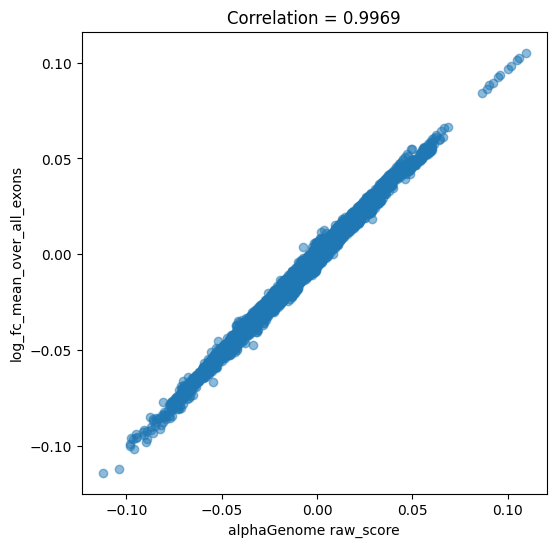

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# Example
# df = pd.read_feather("data.feather")

x = filtered["raw_score"]
y = filtered["log_fc_mean_over_all_exons"]

# Correlation
corr = x.corr(y)

print("Pearson correlation:", corr)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.5)

plt.xlabel("alphaGenome raw_score")
plt.ylabel("log_fc_mean_over_all_exons")
plt.title(f"Correlation = {corr:.4f}")

plt.show()

In [37]:
exclude_tracks = [
    'UBERON:0000473 gtex Testis polyA plus RNA-seq',
    'UBERON:0000473 polyA plus RNA-seq',
    'UBERON:0000945 gtex Stomach polyA plus RNA-seq',
    'UBERON:0000945 polyA plus RNA-seq',
    'UBERON:0000992 gtex Ovary polyA plus RNA-seq',
    'UBERON:0000992 polyA plus RNA-seq',
    'UBERON:0002106 gtex Spleen polyA plus RNA-seq',
    'UBERON:0002106 polyA plus RNA-seq',
    'UBERON:0002369 gtex Adrenal_Gland polyA plus RNA-seq',
    'UBERON:0002369 polyA plus RNA-seq'
]

df_filtered = merged[~merged["track_name"].isin(exclude_tracks)]

In [38]:
correlations_filtered = {}

for col in candidate_cols:
    corr = df_filtered["raw_score"].corr(df_filtered[col])
    correlations_filtered[col] = corr
    print(f"Correlation between raw_score and {col}: {corr:.4f}")

best_col = max(correlations_filtered, key=correlations_filtered.get)

print("\nBest correlation:")

print(best_col, correlations_filtered[best_col])

Correlation between raw_score and median_of_exon_medians_ref: -0.0201
Correlation between raw_score and median_of_exon_medians_alt: 0.0133
Correlation between raw_score and log10_median_of_exon_medians_ref: -0.0805
Correlation between raw_score and log10_median_of_exon_medians_alt: -0.0516
Correlation between raw_score and delta_median_of_exon_medians: 0.7898
Correlation between raw_score and log_fc_median_of_exon_medians: 0.9364
Correlation between raw_score and median_of_exon_means_ref: -0.0193
Correlation between raw_score and median_of_exon_means_alt: 0.0140
Correlation between raw_score and log10_median_of_exon_means_ref: -0.0801
Correlation between raw_score and log10_median_of_exon_means_alt: -0.0515
Correlation between raw_score and delta_median_of_exon_means: 0.7994
Correlation between raw_score and log_fc_median_of_exon_means: 0.9398
Correlation between raw_score and mean_of_exon_means_ref: 0.0063
Correlation between raw_score and mean_of_exon_means_alt: 0.0438
Correlation be

In [60]:
import numpy as np

diff = x - y

mae = np.mean(np.abs(diff))
rmse = np.sqrt(np.mean(diff**2))

print("MAE:", mae)
print("RMSE:", rmse)

print("mean", np.mean(diff))

MAE: 0.0013298378168706301
RMSE: 0.0018103155395263015
mean 0.0007270247446535739
